# Heart Failure Prediction Project
## Using Machine Learning to Predict if a Patient will Survive or Not

**What we will do step by step:**
1. Load the data
2. Look at the data (EDA)
3. Clean the data
4. Train machine learning models
5. Compare which model is best
6. Explain the predictions using SHAP

In [2]:
# CELL 1 - Install Libraries
# Run this first before anything else

!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap

Defaulting to user installation because normal site-packages is not writeable
  Using cached shap-0.51.0-cp312-cp312-win_amd64.whl.metadata (26 kB)
  Using cached numpy-2.0.2-cp312-cp312-win_amd64.whl.metadata (59 kB)
Using cached shap-0.51.0-cp312-cp312-win_amd64.whl (556 kB)
Using cached numpy-2.0.2-cp312-cp312-win_amd64.whl (15.6 MB)

  Attempting uninstall: numpy

    Found existing installation: numpy 1.26.4

   ---------------------------------------- 0/2 [numpy]
    Uninstalling numpy-1.26.4:
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bentoml 1.0.25 requires opentelemetry-api==1.18.0, but you have opentelemetry-api 1.39.1 which is incompatible.
bentoml 1.0.25 requires opentelemetry-instrumentation==0.39b0, but you have opentelemetry-instrumentation 0.55b1 which is incompatible.
bentoml 1.0.25 requires opentelemetry-instrumentation-asgi==0.39b0, but you have opentelemetry-instrumentation-asgi 0.55b1 which is incompatible.
bentoml 1.0.25 requires opentelemetry-sdk==1.18.0, but you have opentelemetry-sdk 1.39.1 which is incompatible.
bentoml 1.0.25 requires opentelemetry-semantic-conventions==0.39b0, but you have opentelemetry-semantic-conventions 0.60b1 which is incompatible.
bentoml 1.0.25 requires opentelemetry-util-http==0.39b0, but you have opentelemetry-util-http 0.55b

In [3]:
# STEP 2 - Install compatible versions
!pip install numpy==1.26.4
!pip install numba==0.59.1
!pip install shap==0.44.1

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bentoml 1.0.25 requires opentelemetry-api==1.18.0, but you have opentelemetry-api 1.39.1 which is incompatible.
bentoml 1.0.25 requires opentelemetry-instrumentation==0.39b0, but you have opentelemetry-instrumentation 0.55b1 which is incompatible.
bentoml 1.0.25 requires opentelemetry-instrumentation-asgi==0.39b0, but you have opentelemetry-instrumentation-asgi 0.55b1 which is incompatible.
bentoml 1.0.25 requires opentelemetry-sdk==1.18.0, but you have opentelemetry-sdk 1.39.1 which is incompatible.
bentoml 1.0.25 requires opentelemetry-semantic-conventions==0.39b0, but you have opentelemetry-semantic-conventions 0.60b1 which is incompatible.
bentoml 1.0.25 requires opentelemetry-util-http==0.39b0, but you have opentelemetry-util-http 0.55b1 which is incompatible.
bentoml 1.0.25 requires pynvml<12, but you have p

Defaulting to user installation because normal site-packages is not writeable
  Using cached numba-0.59.1-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.42.0-cp312-cp312-win_amd64.whl.metadata (4.9 kB)
Using cached numba-0.59.1-cp312-cp312-win_amd64.whl (2.7 MB)
   ---------------------------------------- 0.0/28.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/28.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/28.1 MB ? eta -:--:--
    --------------------------------------- 0.5/28.1 MB 2.1 MB/s eta 0:00:14
   - -------------------------------------- 1.0/28.1 MB 2.1 MB/s eta 0:00:13
   -- ------------------------------------- 1.8/28.1 MB 2.5 MB/s eta 0:00:11
   ---- ----------------------------------- 2.9/28.1 MB 3.1 MB/s eta 0:00:09
   ---- ----------------------------------- 3.1/28.1 MB 3.2 MB/s eta 0:00:08
   ---- ----------------------------------- 3.1/28.1 MB 3.2 MB/s eta 0:00:08
   ----- ---------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
     --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
     ------------------------------------- -- 1.0/1.1 MB 3.6 MB/s eta 0:00:01
     ---------------------------------------- 1.1/1.1 MB 1.9 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build shap


  error: subprocess-exited-with-error
  
  × Building wheel for shap (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [215 lines of output]
      Attempting to build SHAP: with_binary=True, with_cuda=True (Attempt 1)
      The nvcc binary could not be located in your $PATH. Either add it to your path, or set $CUDAHOME to enable CUDA.
      Exception occurred during setup, Error building cuda module: TypeError('cannot unpack non-iterable NoneType object')
      Retrying SHAP build without cuda extension...
      Attempting to build SHAP: with_binary=True, with_cuda=False (Attempt 2)
      C:\Users\aryan\AppData\Local\Temp\pip-build-env-69m1tmnq\overlay\Lib\site-packages\setuptools\config\_apply_pyprojecttoml.py:82: SetuptoolsDeprecationWarning: `project.license` as a TOML table is deprecated
      !!
      
              ********************************************************************************
              Please use a simple string containing a SPDX expression 

In [4]:
# !pip install shap

^C


In [5]:
# CELL 2 - Import Libraries
# These are tools we need for our project

import pandas as pd           # for working with tables/data
import numpy as np            # for math operations
import matplotlib.pyplot as plt  # for making charts
import seaborn as sns         # for pretty charts
import warnings
warnings.filterwarnings('ignore')  # hide unnecessary warnings

# For splitting data and scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# For checking how good our model is
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve

# For explaining predictions
import shap

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
# CELL 3 - Load the Dataset
# We are loading the Heart Failure dataset from the internet

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Show first 5 rows
df.head()

Dataset loaded successfully!
Number of rows: 299
Number of columns: 13


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [7]:
# CELL 4 - Understand the Data (EDA Part 1)
# Let's look at basic information about our dataset

# What columns do we have and what type of data
print("Column Names and Data Types:")
print(df.dtypes)

print("\n------------------------------------")

# Basic statistics like min, max, average
print("Basic Statistics:")
print(df.describe())

print("\n------------------------------------")

# Check for missing values
print("Missing Values in each column:")
print(df.isnull().sum())

print("\n------------------------------------")

# How many patients survived vs died
print("How many patients Survived (0) vs Died (1):")
print(df['DEATH_EVENT'].value_counts())
print("\nSurvived:", (df['DEATH_EVENT'] == 0).sum())
print("Died:", (df['DEATH_EVENT'] == 1).sum())

Column Names and Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

------------------------------------
Basic Statistics:
              age     anaemia  creatinine_phosphokinase    diabetes  \
count  299.000000  299.000000                299.000000  299.000000   
mean    60.833893    0.431438                581.839465    0.418060   
std     11.894809    0.496107                970.287881    0.494067   
min     40.000000    0.000000                 23.000000    0.000000   
25%     51.000000    0.000000                116.500000    0.000000   
50%    

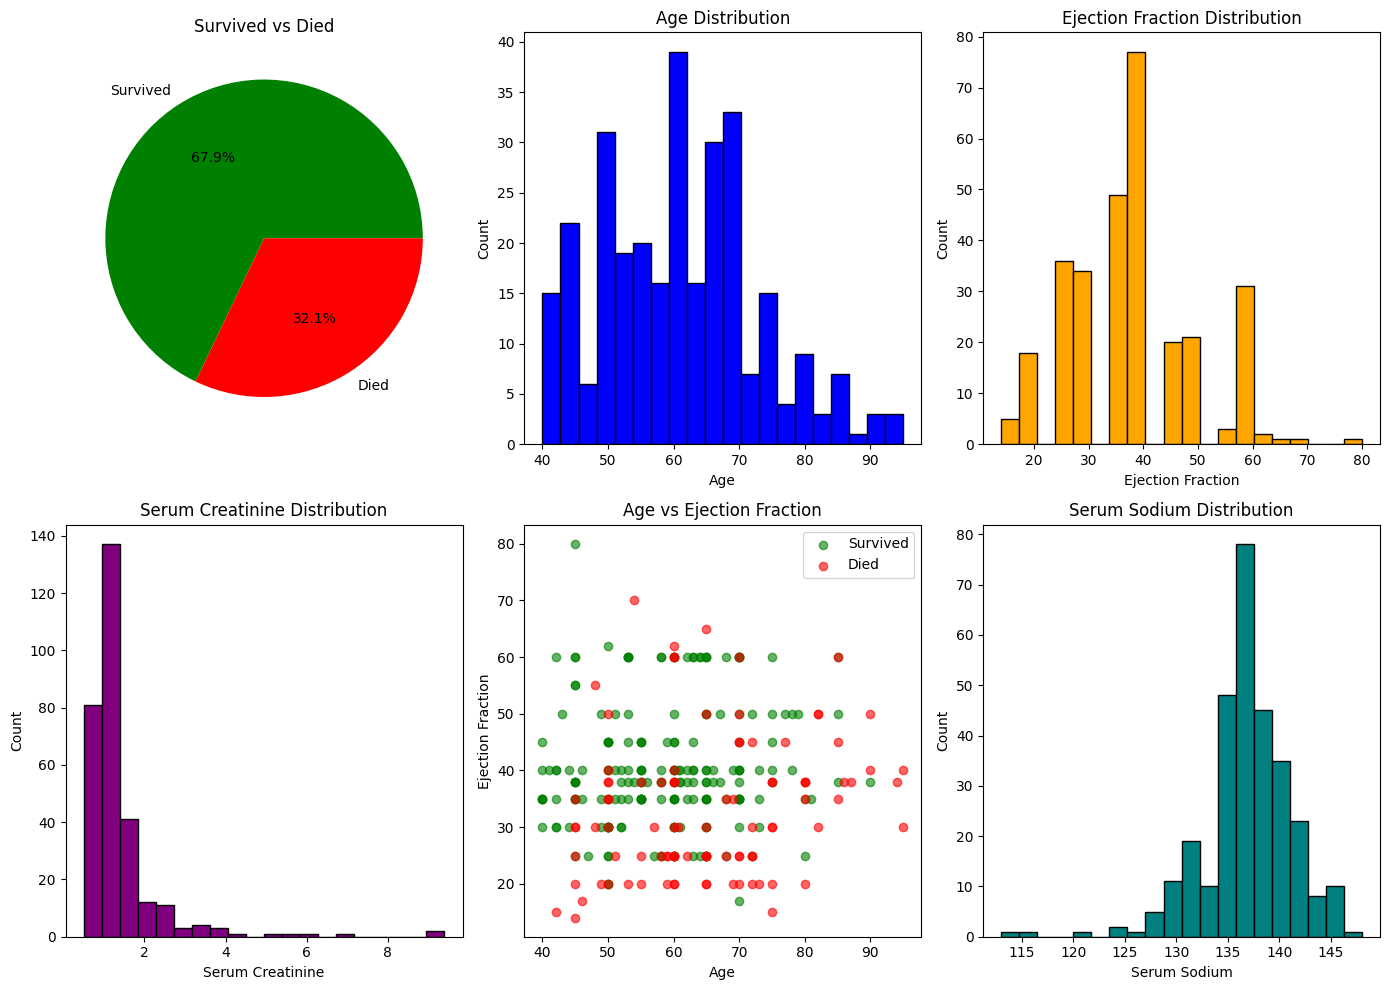

Charts saved!


In [8]:
# CELL 5 - Visualizations Part 1
# Let's make some simple charts to understand the data

plt.figure(figsize=(14, 10))

# Chart 1: How many survived vs died (Pie Chart)
plt.subplot(2, 3, 1)
df['DEATH_EVENT'].value_counts().plot.pie(
    labels=['Survived', 'Died'],
    colors=['green', 'red'],
    autopct='%1.1f%%'
)
plt.title('Survived vs Died')
plt.ylabel('')

# Chart 2: Age distribution
plt.subplot(2, 3, 2)
plt.hist(df['age'], bins=20, color='blue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

# Chart 3: Ejection Fraction distribution
plt.subplot(2, 3, 3)
plt.hist(df['ejection_fraction'], bins=20, color='orange', edgecolor='black')
plt.title('Ejection Fraction Distribution')
plt.xlabel('Ejection Fraction')
plt.ylabel('Count')

# Chart 4: Serum Creatinine distribution
plt.subplot(2, 3, 4)
plt.hist(df['serum_creatinine'], bins=20, color='purple', edgecolor='black')
plt.title('Serum Creatinine Distribution')
plt.xlabel('Serum Creatinine')
plt.ylabel('Count')

# Chart 5: Age vs Ejection Fraction (colored by death event)
plt.subplot(2, 3, 5)
survived = df[df['DEATH_EVENT'] == 0]
died = df[df['DEATH_EVENT'] == 1]
plt.scatter(survived['age'], survived['ejection_fraction'], color='green', label='Survived', alpha=0.6)
plt.scatter(died['age'], died['ejection_fraction'], color='red', label='Died', alpha=0.6)
plt.title('Age vs Ejection Fraction')
plt.xlabel('Age')
plt.ylabel('Ejection Fraction')
plt.legend()

# Chart 6: Serum Sodium distribution
plt.subplot(2, 3, 6)
plt.hist(df['serum_sodium'], bins=20, color='teal', edgecolor='black')
plt.title('Serum Sodium Distribution')
plt.xlabel('Serum Sodium')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('charts1.png')
plt.show()
print("Charts saved!")

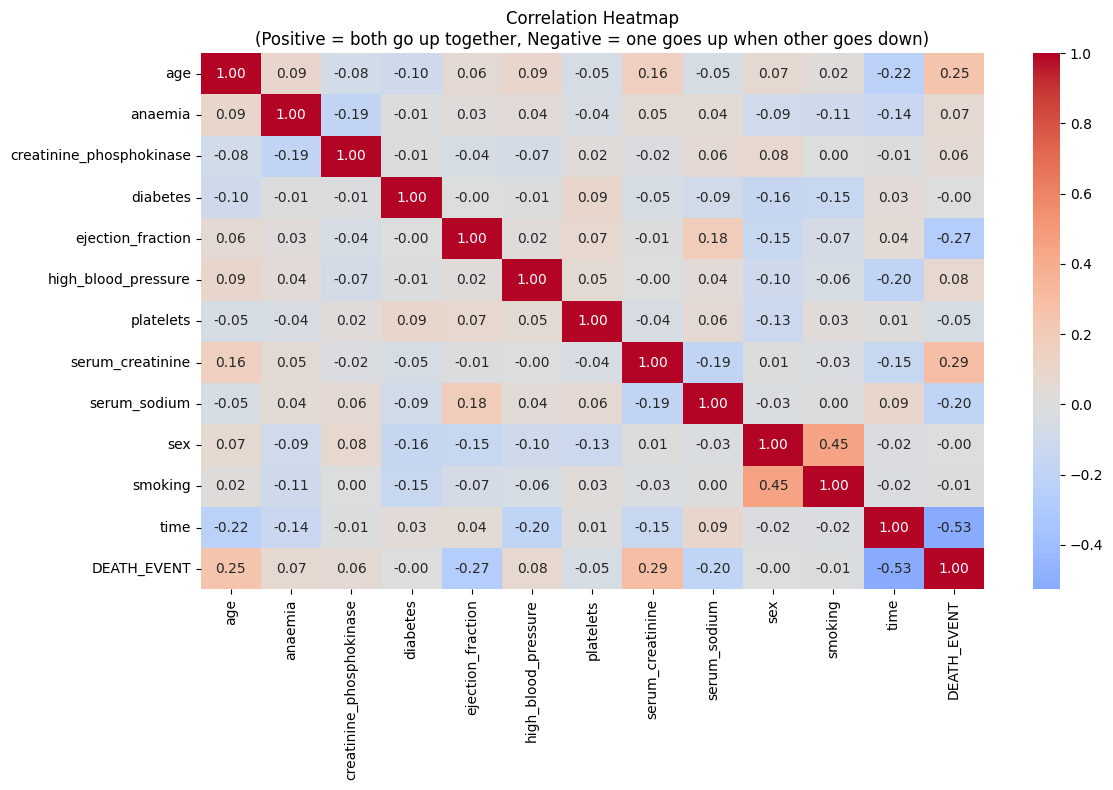

Correlation with DEATH_EVENT (target):
DEATH_EVENT                 1.000000
serum_creatinine            0.294278
age                         0.253729
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
diabetes                   -0.001943
sex                        -0.004316
smoking                    -0.012623
platelets                  -0.049139
serum_sodium               -0.195204
ejection_fraction          -0.268603
time                       -0.526964
Name: DEATH_EVENT, dtype: float64


In [9]:
# CELL 6 - Visualizations Part 2
# Correlation Heatmap - shows which features are related to each other

plt.figure(figsize=(12, 8))

# Calculate correlation
corr = df.corr()

# Draw heatmap
sns.heatmap(
    corr,
    annot=True,        # show numbers inside boxes
    fmt='.2f',         # 2 decimal places
    cmap='coolwarm',   # red-blue color scheme
    center=0
)
plt.title('Correlation Heatmap\n(Positive = both go up together, Negative = one goes up when other goes down)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

# Show which features are most related to DEATH_EVENT
print("Correlation with DEATH_EVENT (target):")
print(df.corr()['DEATH_EVENT'].sort_values(ascending=False))

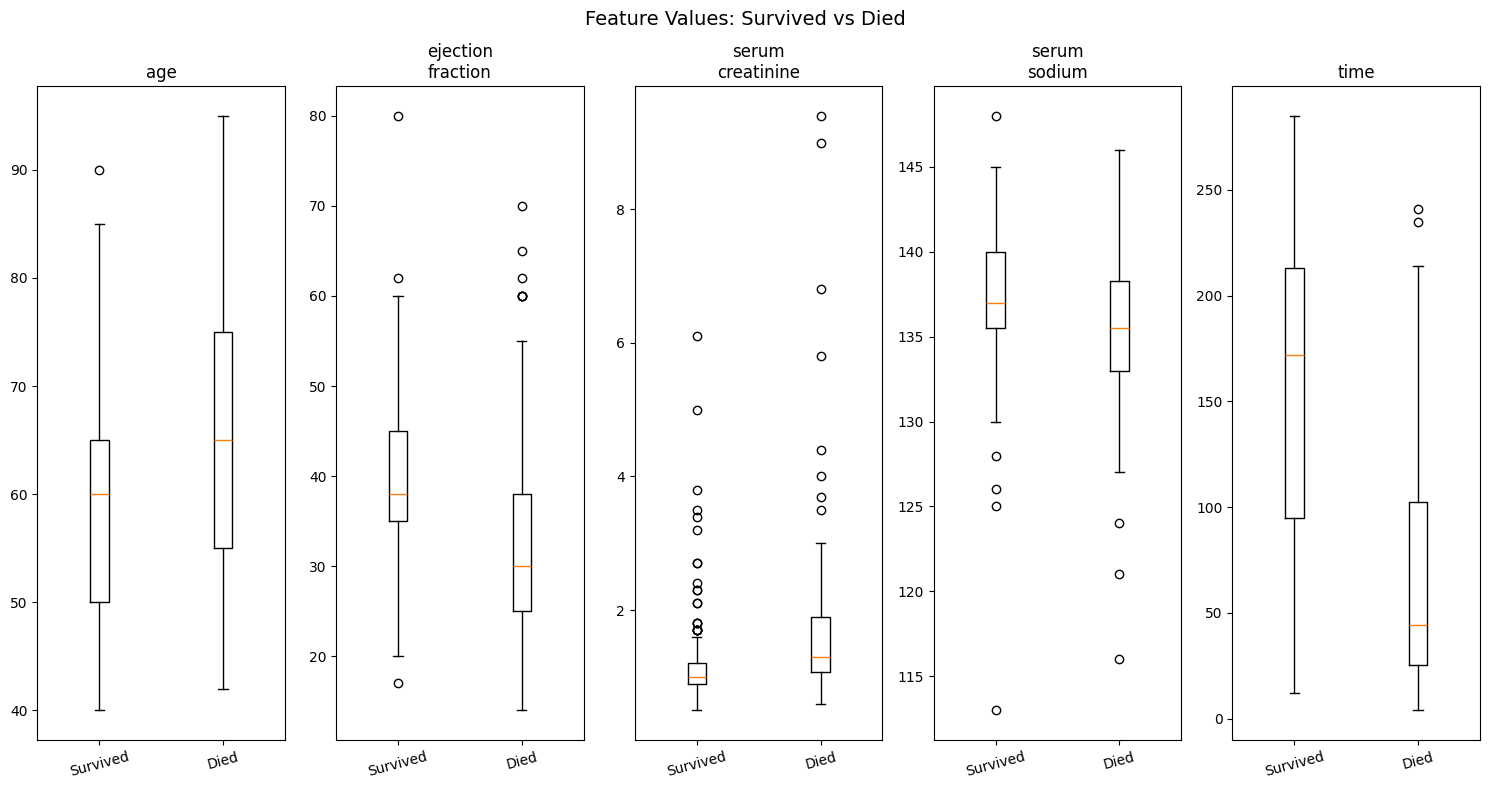

Observation: Lower ejection_fraction and higher serum_creatinine are linked to death


In [10]:
# CELL 7 - Visualizations Part 3
# Boxplots - compare feature values for Survived vs Died

# These are the most important features based on correlation
important_features = ['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium', 'time']

plt.figure(figsize=(15, 8))

for i, feature in enumerate(important_features):
    plt.subplot(1, 5, i + 1)
    
    # Get values for survived and died separately
    survived_values = df[df['DEATH_EVENT'] == 0][feature]
    died_values = df[df['DEATH_EVENT'] == 1][feature]
    
    # Create boxplot
    plt.boxplot([survived_values, died_values], labels=['Survived', 'Died'])
    plt.title(feature.replace('_', '\n'))
    plt.xticks(rotation=15)

plt.suptitle('Feature Values: Survived vs Died', fontsize=14)
plt.tight_layout()
plt.savefig('boxplots.png')
plt.show()

print("Observation: Lower ejection_fraction and higher serum_creatinine are linked to death")

In [11]:
# CELL 8 - Data Preprocessing
# Prepare data for machine learning

# Step 1: Separate features (X) and target (y)
# X = input features (what we know about the patient)
# y = what we want to predict (0 = survived, 1 = died)
X = df.drop('DEATH_EVENT', axis=1)   # all columns except target
y = df['DEATH_EVENT']                # the target column

print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)
print("\nFeature columns:", list(X.columns))

# Step 2: Split data into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # so we get same split every time
    stratify=y           # keep same ratio of 0 and 1 in both splits
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# Step 3: Scale the features
# This makes all features have similar range (important for SVM and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn scale from training data
X_test_scaled = scaler.transform(X_test)          # apply same scale to test data

# Convert back to DataFrame so we can see column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("\nScaling done! Data is ready for training.")

Features shape (X): (299, 12)
Target shape (y): (299,)

Feature columns: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']

Training samples: 239
Testing samples: 60

Scaling done! Data is ready for training.


In [12]:
# CELL 9 - Feature Engineering
# Create new features from existing ones to help the model

# We create simple new features based on medical knowledge

def add_new_features(data):
    data = data.copy()  # don't change original data
    
    # Feature 1: Low ejection fraction (below 40% is a medical risk)
    data['low_ejection'] = (data['ejection_fraction'] < 40).astype(int)
    # 1 means low (risky), 0 means normal
    
    # Feature 2: Elderly patient (above 65 years)
    data['is_elderly'] = (data['age'] > 65).astype(int)
    
    # Feature 3: High creatinine (kidney problem indicator)
    data['high_creatinine'] = (data['serum_creatinine'] > 1.5).astype(int)
    
    # Feature 4: Low sodium (bad for heart)
    data['low_sodium'] = (data['serum_sodium'] < 135).astype(int)
    
    return data

# Apply feature engineering
X_train_new = add_new_features(X_train_scaled)
X_test_new  = add_new_features(X_test_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("New number of features:", X_train_new.shape[1])
print("\nNew features added:")
print("  - low_ejection  (1 if ejection_fraction < 40)")
print("  - is_elderly    (1 if age > 65)")
print("  - high_creatinine (1 if serum_creatinine > 1.5)")
print("  - low_sodium    (1 if serum_sodium < 135)")

# Show first 5 rows of new features
print("\nSample of new features:")
print(X_train_new[['low_ejection', 'is_elderly', 'high_creatinine', 'low_sodium']].head())

Original number of features: 12
New number of features: 16

New features added:
  - low_ejection  (1 if ejection_fraction < 40)
  - is_elderly    (1 if age > 65)
  - high_creatinine (1 if serum_creatinine > 1.5)
  - low_sodium    (1 if serum_sodium < 135)

Sample of new features:
   low_ejection  is_elderly  high_creatinine  low_sodium
0             1           0                0           1
1             1           0                0           1
2             1           0                0           1
3             1           0                0           1
4             1           0                0           1


In [13]:
# CELL 10 - Train All Models
# We train 5 different models and compare them

# Create a dictionary with all models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(probability=True, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0),
    'KNN':                 KNeighborsClassifier(n_neighbors=5)
}

# Store results here
results = {}
trained_models = {}

print("Training all models...\n")

for model_name, model in models.items():
    
    # Step 1: Train the model
    model.fit(X_train_new, y_train)
    
    # Step 2: Make predictions on test data
    y_pred = model.predict(X_test_new)
    y_prob = model.predict_proba(X_test_new)[:, 1]  # probability of dying
    
    # Step 3: Calculate accuracy and other scores
    accuracy  = accuracy_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_prob)
    
    # Save results
    results[model_name] = {
        'Accuracy': round(accuracy, 4),
        'ROC-AUC':  round(roc_auc, 4)
    }
    trained_models[model_name] = model
    
    print(f"{model_name}")
    print(f"  Accuracy = {accuracy:.4f}")
    print(f"  ROC-AUC  = {roc_auc:.4f}")
    print()

print("All models trained!")

Training all models...

Logistic Regression
  Accuracy = 0.8333
  ROC-AUC  = 0.8691

Random Forest
  Accuracy = 0.8500
  ROC-AUC  = 0.8960

SVM
  Accuracy = 0.7500
  ROC-AUC  = 0.8447

XGBoost
  Accuracy = 0.8167
  ROC-AUC  = 0.8318

KNN
  Accuracy = 0.7000
  ROC-AUC  = 0.7920

All models trained!


Model Comparison Table (sorted by ROC-AUC):
                     Accuracy  ROC-AUC
Random Forest          0.8500   0.8960
Logistic Regression    0.8333   0.8691
SVM                    0.7500   0.8447
XGBoost                0.8167   0.8318
KNN                    0.7000   0.7920

Best Model: Random Forest
Best ROC-AUC Score: 0.896


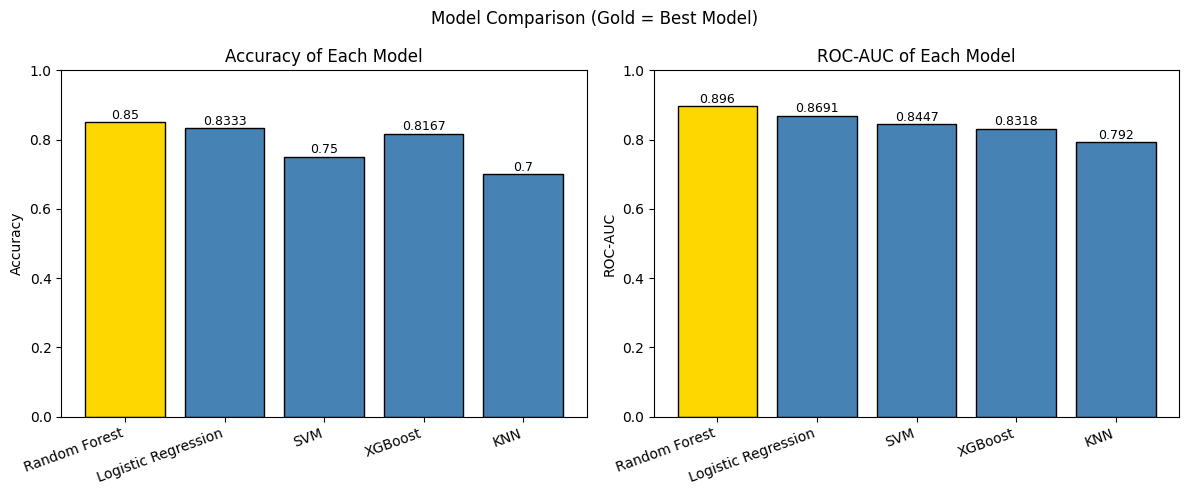

In [14]:
# CELL 11 - Compare All Models
# Show results in a table and chart

# Create a results table
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print("Model Comparison Table (sorted by ROC-AUC):")
print(results_df)

# Find the best model
best_model_name = results_df['ROC-AUC'].idxmax()
print(f"\nBest Model: {best_model_name}")
print(f"Best ROC-AUC Score: {results_df['ROC-AUC'].max()}")

# Make a bar chart to compare models
plt.figure(figsize=(12, 5))

# Chart 1: Accuracy comparison
plt.subplot(1, 2, 1)
colors = ['gold' if name == best_model_name else 'steelblue' for name in results_df.index]
plt.bar(results_df.index, results_df['Accuracy'], color=colors, edgecolor='black')
plt.title('Accuracy of Each Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
for i, val in enumerate(results_df['Accuracy']):
    plt.text(i, val + 0.01, str(val), ha='center', fontsize=9)

# Chart 2: ROC-AUC comparison
plt.subplot(1, 2, 2)
plt.bar(results_df.index, results_df['ROC-AUC'], color=colors, edgecolor='black')
plt.title('ROC-AUC of Each Model')
plt.ylabel('ROC-AUC')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
for i, val in enumerate(results_df['ROC-AUC']):
    plt.text(i, val + 0.01, str(val), ha='center', fontsize=9)

plt.suptitle('Model Comparison (Gold = Best Model)', fontsize=12)
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

Testing KNN with different values of K (1 to 15)...

K= 1  Accuracy=0.7167  ROC-AUC=0.6091
K= 2  Accuracy=0.7167  ROC-AUC=0.6232
K= 3  Accuracy=0.7000  ROC-AUC=0.7208
K= 4  Accuracy=0.7167  ROC-AUC=0.7754
K= 5  Accuracy=0.7000  ROC-AUC=0.7920
K= 6  Accuracy=0.7333  ROC-AUC=0.7625
K= 7  Accuracy=0.7500  ROC-AUC=0.7458
K= 8  Accuracy=0.7500  ROC-AUC=0.7625
K= 9  Accuracy=0.7333  ROC-AUC=0.7721
K=10  Accuracy=0.7333  ROC-AUC=0.7824
K=11  Accuracy=0.7333  ROC-AUC=0.7997
K=12  Accuracy=0.7333  ROC-AUC=0.8036
K=13  Accuracy=0.7500  ROC-AUC=0.7946
K=14  Accuracy=0.7333  ROC-AUC=0.8055
K=15  Accuracy=0.7667  ROC-AUC=0.8068

Best K value: 15


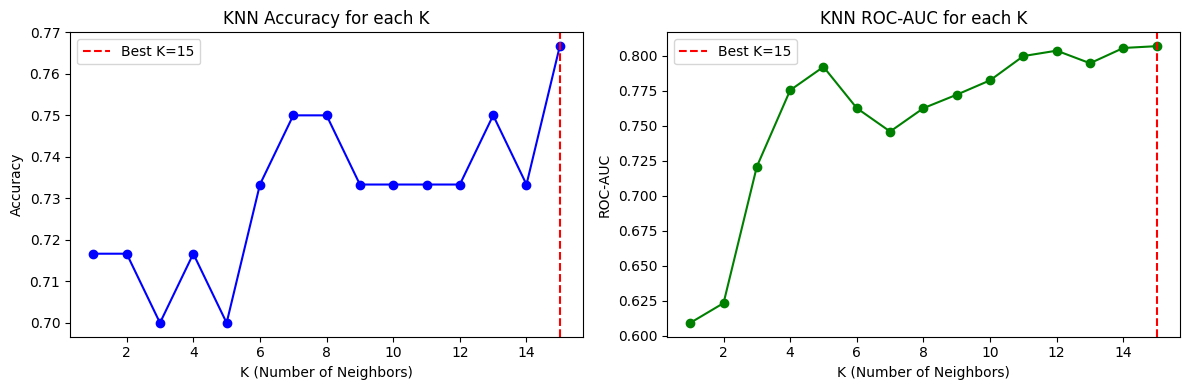


KNN vs Best Model Comparison:
  KNN Accuracy:           0.7
  Random Forest Accuracy: 0.85
  KNN ROC-AUC:            0.792
  Random Forest ROC-AUC:  0.896


In [15]:
# CELL 12 - KNN Model - Detailed Analysis
# Let's study KNN more carefully by trying different K values

print("Testing KNN with different values of K (1 to 15)...\n")

k_values = list(range(1, 16))  # K from 1 to 15
accuracy_list = []
roc_auc_list  = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_new, y_train)
    y_pred_k = knn.predict(X_test_new)
    y_prob_k = knn.predict_proba(X_test_new)[:, 1]
    
    acc = accuracy_score(y_test, y_pred_k)
    auc_score = roc_auc_score(y_test, y_prob_k)
    
    accuracy_list.append(acc)
    roc_auc_list.append(auc_score)
    print(f"K={k:2d}  Accuracy={acc:.4f}  ROC-AUC={auc_score:.4f}")

# Find best K
best_k = k_values[roc_auc_list.index(max(roc_auc_list))]
print(f"\nBest K value: {best_k}")

# Plot the results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_values, accuracy_list, marker='o', color='blue')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.title('KNN Accuracy for each K')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(k_values, roc_auc_list, marker='o', color='green')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.title('KNN ROC-AUC for each K')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('ROC-AUC')
plt.legend()

plt.tight_layout()
plt.savefig('knn_analysis.png')
plt.show()

# Compare KNN vs Best Model
print("\nKNN vs Best Model Comparison:")
print(f"  KNN Accuracy:           {results['KNN']['Accuracy']}")
print(f"  {best_model_name} Accuracy: {results[best_model_name]['Accuracy']}")
print(f"  KNN ROC-AUC:            {results['KNN']['ROC-AUC']}")
print(f"  {best_model_name} ROC-AUC:  {results[best_model_name]['ROC-AUC']}")

Detailed Evaluation of Best Model: Random Forest

Classification Report:
(precision = how many we predicted as died were actually died)
(recall = how many actual deaths did we correctly find)

              precision    recall  f1-score   support

    Survived       0.85      0.95      0.90        41
        Died       0.86      0.63      0.73        19

    accuracy                           0.85        60
   macro avg       0.85      0.79      0.81        60
weighted avg       0.85      0.85      0.84        60



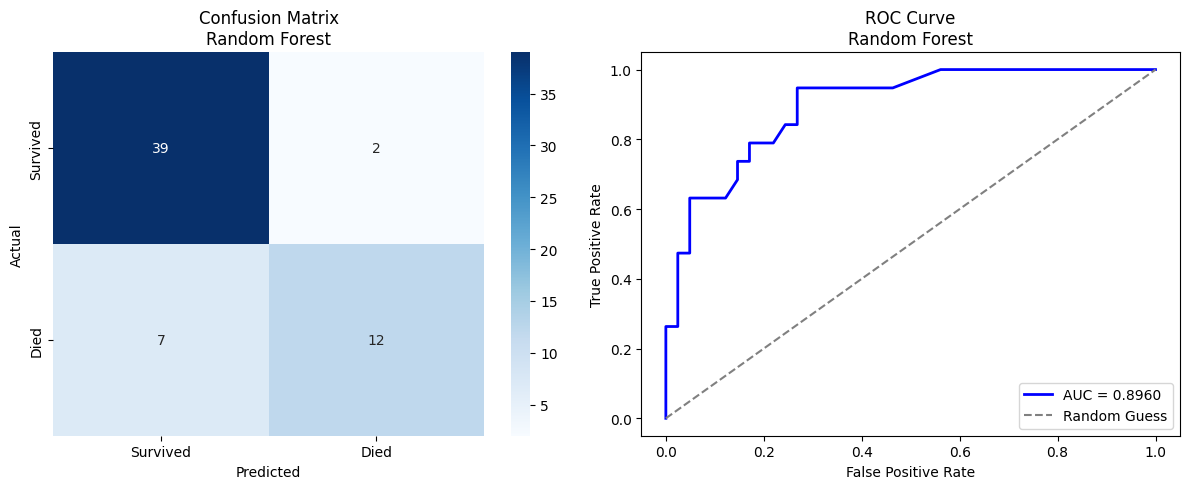


Confusion Matrix Explanation:
  Correctly predicted Survived: 39
  Wrongly predicted as Died (should be Survived): 2
  Wrongly predicted as Survived (should be Died): 7
  Correctly predicted Died: 12


In [16]:
# CELL 13 - Evaluate Best Model in Detail
# Show confusion matrix and classification report for the best model

print(f"Detailed Evaluation of Best Model: {best_model_name}")
print("=" * 50)

best_model = trained_models[best_model_name]

# Make predictions
y_pred_best = best_model.predict(X_test_new)
y_prob_best = best_model.predict_proba(X_test_new)[:, 1]

# Classification Report
print("\nClassification Report:")
print("(precision = how many we predicted as died were actually died)")
print("(recall = how many actual deaths did we correctly find)")
print()
print(classification_report(y_test, y_pred_best, target_names=['Survived', 'Died']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(12, 5))

# Chart 1: Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',              # show as whole numbers
    cmap='Blues',
    xticklabels=['Survived', 'Died'],
    yticklabels=['Survived', 'Died']
)
plt.title(f'Confusion Matrix\n{best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Chart 2: ROC Curve
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
auc_val = roc_auc_score(y_test, y_prob_best)
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'AUC = {auc_val:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.title(f'ROC Curve\n{best_model_name}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.savefig('best_model_evaluation.png')
plt.show()

# Explain what confusion matrix means
print("\nConfusion Matrix Explanation:")
print(f"  Correctly predicted Survived: {cm[0][0]}")
print(f"  Wrongly predicted as Died (should be Survived): {cm[0][1]}")
print(f"  Wrongly predicted as Survived (should be Died): {cm[1][0]}")
print(f"  Correctly predicted Died: {cm[1][1]}")

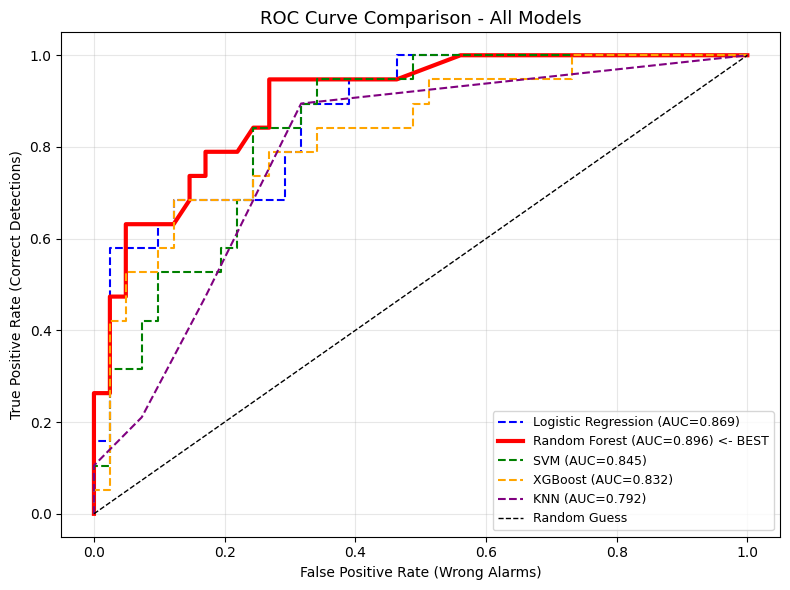

Higher AUC = Better model
AUC of 1.0 = Perfect model
AUC of 0.5 = No better than random guessing


In [17]:
# CELL 14 - ROC Curves for All Models
# Compare all models on one ROC chart

plt.figure(figsize=(8, 6))

# Color for each model
colors = ['blue', 'red', 'green', 'orange', 'purple']

for (model_name, model), color in zip(trained_models.items(), colors):
    y_prob = model.predict_proba(X_test_new)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    
    # Make the best model line thicker
    if model_name == best_model_name:
        plt.plot(fpr, tpr, color=color, linewidth=3,
                 label=f'{model_name} (AUC={auc_score:.3f}) <- BEST')
    else:
        plt.plot(fpr, tpr, color=color, linewidth=1.5,
                 label=f'{model_name} (AUC={auc_score:.3f})', linestyle='--')

# Random guess line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')

plt.title('ROC Curve Comparison - All Models', fontsize=13)
plt.xlabel('False Positive Rate (Wrong Alarms)')
plt.ylabel('True Positive Rate (Correct Detections)')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('all_roc_curves.png')
plt.show()

print("Higher AUC = Better model")
print("AUC of 1.0 = Perfect model")
print("AUC of 0.5 = No better than random guessing")

SHAP Analysis - Explaining Model Predictions
SHAP tells us: which features pushed the prediction towards Died or Survived
Positive SHAP value = pushed towards predicting Death
Negative SHAP value = pushed towards predicting Survival

SHAP values calculated!
Shape of SHAP values: (60, 16)
(Each row = one patient, each column = one feature)

Plotting SHAP Summary (Feature Importance)...


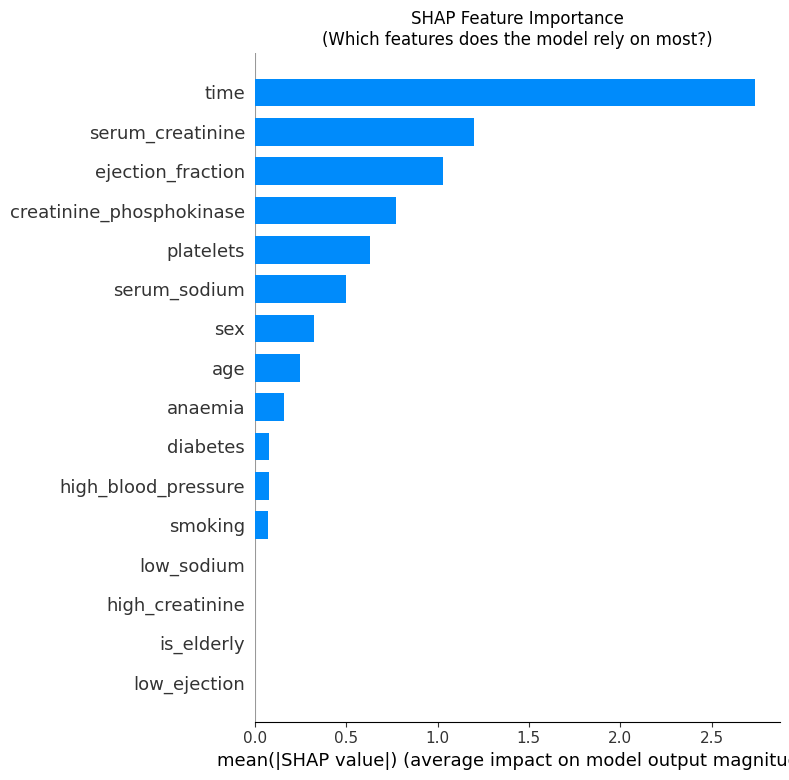

Plotting SHAP Summary Dot Plot (Direction of effect)...


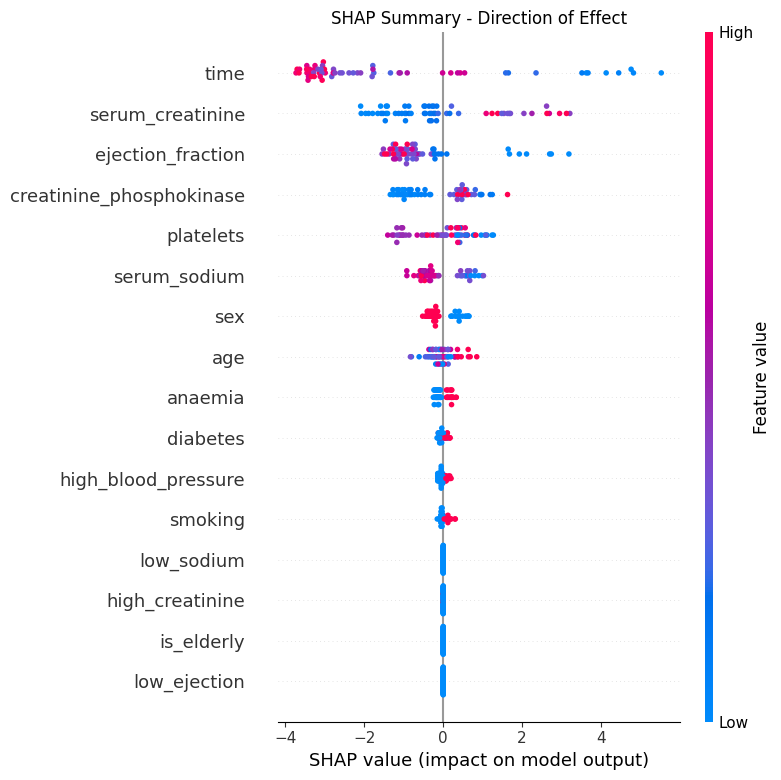


How to read the dot plot:
  Red dots = high feature value
  Blue dots = low feature value
  Right side (positive) = increases death risk
  Left side (negative)  = decreases death risk


In [18]:
# CELL 15 - SHAP - Explainable AI
# Understand WHY the model makes certain predictions

print("SHAP Analysis - Explaining Model Predictions")
print("=" * 50)
print("SHAP tells us: which features pushed the prediction towards Died or Survived")
print("Positive SHAP value = pushed towards predicting Death")
print("Negative SHAP value = pushed towards predicting Survival")
print()

# We use XGBoost for SHAP because it works best with TreeExplainer
xgb_model = trained_models['XGBoost']

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for test data
shap_values = explainer.shap_values(X_test_new)

print("SHAP values calculated!")
print("Shape of SHAP values:", shap_values.shape)
print("(Each row = one patient, each column = one feature)")

# Plot 1: Summary plot (most important)
# This shows which features matter most
print("\nPlotting SHAP Summary (Feature Importance)...")
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_new,
    feature_names=X_test_new.columns.tolist(),
    show=False,
    plot_type='bar'   # simple bar chart showing importance
)
plt.title('SHAP Feature Importance\n(Which features does the model rely on most?)')
plt.tight_layout()
plt.savefig('shap_importance.png')
plt.show()

# Plot 2: Detailed dot plot
print("Plotting SHAP Summary Dot Plot (Direction of effect)...")
shap.summary_plot(
    shap_values,
    X_test_new,
    feature_names=X_test_new.columns.tolist(),
    show=False
)
plt.title('SHAP Summary - Direction of Effect')
plt.tight_layout()
plt.savefig('shap_dot_plot.png')
plt.show()

print("\nHow to read the dot plot:")
print("  Red dots = high feature value")
print("  Blue dots = low feature value")
print("  Right side (positive) = increases death risk")
print("  Left side (negative)  = decreases death risk")

In [19]:
# CELL 16 - Final Summary
# A simple summary of everything we did

print("=" * 55)
print("       FINAL PROJECT SUMMARY")
print("=" * 55)

print(f"""
DATASET:
  Total patients   : {len(df)}
  Survived         : {(df['DEATH_EVENT']==0).sum()}
  Died             : {(df['DEATH_EVENT']==1).sum()}
  Features used    : {X_train_new.shape[1]} (original + engineered)

MODELS TRAINED:
  1. Logistic Regression
  2. Random Forest
  3. SVM
  4. XGBoost
  5. KNN (compared as baseline)
""")

print("ALL MODEL RESULTS:")
print("-" * 40)
results_final = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
print(results_final.to_string())

print(f"""

BEST MODEL    : {best_model_name}
Accuracy      : {results[best_model_name]['Accuracy']}
ROC-AUC       : {results[best_model_name]['ROC-AUC']}

KNN BASELINE  :
Accuracy      : {results['KNN']['Accuracy']}
ROC-AUC       : {results['KNN']['ROC-AUC']}

KEY FINDINGS (from SHAP analysis):
  - 'time' (follow-up period) is the top predictor
  - Low ejection_fraction increases death risk
  - High serum_creatinine increases death risk
  - Low serum_sodium increases death risk

CONCLUSION:
  The {best_model_name} model performed best.
  It outperforms the KNN baseline.
  SHAP analysis makes the model explainable for doctors.
""")

print("Project Complete!")

       FINAL PROJECT SUMMARY

DATASET:
  Total patients   : 299
  Survived         : 203
  Died             : 96
  Features used    : 16 (original + engineered)

MODELS TRAINED:
  1. Logistic Regression
  2. Random Forest
  3. SVM
  4. XGBoost
  5. KNN (compared as baseline)

ALL MODEL RESULTS:
----------------------------------------
                     Accuracy  ROC-AUC
Random Forest          0.8500   0.8960
Logistic Regression    0.8333   0.8691
SVM                    0.7500   0.8447
XGBoost                0.8167   0.8318
KNN                    0.7000   0.7920


BEST MODEL    : Random Forest
Accuracy      : 0.85
ROC-AUC       : 0.896

KNN BASELINE  :
Accuracy      : 0.7
ROC-AUC       : 0.792

KEY FINDINGS (from SHAP analysis):
  - 'time' (follow-up period) is the top predictor
  - Low ejection_fraction increases death risk
  - High serum_creatinine increases death risk
  - Low serum_sodium increases death risk

CONCLUSION:
  The Random Forest model performed best.
  It outperforms 

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.4.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.3 MB 3.4 MB/s eta 0:00:04
   ---- ----------------------------------- 1.3/12.3 MB 4.0 MB/s eta 0:00:03
   ------- -------------------------------- 2.4/12.3 MB 4.3 MB/s eta 0:00:03
   ----------- ---------------------------- 3.7/12.3 MB 5.0 MB/s eta 0:00:02
   ----------------- ---------------------- 5.2/12.3 MB 5.5 MB/s eta 0:00:02
   ---------------------- ----------------- 7.1/12.3 MB 6.1 MB/s eta 0:00:01
   ---------------------------- ----------- 8.9/12.3 MB 6.5 MB/s eta 0:00:01
   ---------------------------

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bentoml 1.0.25 requires opentelemetry-api==1.18.0, but you have opentelemetry-api 1.39.1 which is incompatible.
bentoml 1.0.25 requires opentelemetry-instrumentation==0.39b0, but you have opentelemetry-instrumentation 0.55b1 which is incompatible.
bentoml 1.0.25 requires opentelemetry-instrumentation-asgi==0.39b0, but you have opentelemetry-instrumentation-asgi 0.55b1 which is incompatible.
bentoml 1.0.25 requires opentelemetry-sdk==1.18.0, but you have opentelemetry-sdk 1.39.1 which is incompatible.
bentoml 1.0.25 requires opentelemetry-semantic-conventions==0.39b0, but you have opentelemetry-semantic-conventions 0.60b1 which is incompatible.
bentoml 1.0.25 requires opentelemetry-util-http==0.39b0, but you have opentelemetry-util-http 0.55b

In [20]:
# ─────────────────────────────────────────
# PICKLE CELL - Save the Best Model
# Add this cell at the END of your notebook
# ─────────────────────────────────────────

import pickle
import os

# Step 1: Save the best model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print('best_model.pkl saved!')

# Step 2: Save the scaler (very important!)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('scaler.pkl saved!')

# Step 3: Confirm files exist
print('\nFiles saved in folder:')
for file in os.listdir('.'):
    if file.endswith('.pkl'):
        size = os.path.getsize(file)
        print(f'  {file}  ({size} bytes)')

print('\nDone! Now copy best_model.pkl and scaler.pkl to your Flask project folder.')

best_model.pkl saved!
scaler.pkl saved!

Files saved in folder:
  best_model.pkl  (565690 bytes)
  scaler.pkl  (955 bytes)

Done! Now copy best_model.pkl and scaler.pkl to your Flask project folder.


In [21]:
# OPTIONAL - Test loading the saved model
# Run this to make sure the file was saved correctly

import pickle

# Load model back
with open('best_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Load scaler back
with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

# Test prediction with one sample
sample = X_test_new.iloc[[0]]
prediction = loaded_model.predict(sample)
probability = loaded_model.predict_proba(sample)[0][1]

print('Model loaded successfully!')
print('Test prediction:', 'DIED' if prediction[0] == 1 else 'SURVIVED')
print('Death probability:', round(probability * 100, 2), '%')

Model loaded successfully!
Test prediction: SURVIVED
Death probability: 18.0 %
